In [53]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from typing import List, Optional, TypedDict, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import json

# Load environmental variables from .env
load_dotenv()

True

In [54]:
import json
from typing import Any, Dict
from langchain_core.messages import BaseMessage


def dump_state(state: Dict[str, Any], indent: int = 2, show_message_content: bool = True) -> None:
    """
    Pretty print entire LangGraph state including messages.

    Args:
        state: The state dictionary from LangGraph
        indent: Number of spaces for JSON indentation
        show_message_content: If True, shows full message content. If False, shows truncated preview.
    """
    serializable_state = {}

    for key, value in state.items():
        if key == "messages":
            # Convert messages to serializable format
            serializable_state["messages"] = [
                serialize_message(msg, show_full_content=show_message_content)
                for msg in value
            ]
        elif isinstance(value, list):
            # Handle lists that might contain complex objects
            serializable_state[key] = [
                serialize_item(item) for item in value
            ]
        else:
            # Handle other types
            serializable_state[key] = serialize_item(value)

    print(json.dumps(serializable_state, indent=indent, ensure_ascii=False))


def serialize_message(msg: BaseMessage, show_full_content: bool = True) -> Dict[str, Any]:
    """Convert a LangChain message to a serializable dict."""
    content = msg.content if show_full_content else f"{msg.content[:100]}..." if len(msg.content) > 100 else msg.content

    result = {
        "type": msg.type,
        "content": content
    }

    # Include additional fields if present
    if hasattr(msg, 'name') and msg.name:
        result["name"] = msg.name
    if hasattr(msg, 'id') and msg.id:
        result["id"] = msg.id

    return result


def serialize_item(item: Any) -> Any:
    """Serialize various types to JSON-compatible format."""
    if isinstance(item, BaseMessage):
        return serialize_message(item)
    elif hasattr(item, 'dict'):
        # Pydantic models
        return item.dict()
    elif hasattr(item, '__dict__'):
        # Generic objects
        return item.__dict__
    else:
        # Primitive types
        return item


def dump_state_compact(state: Dict[str, Any]) -> None:
    """
    Compact view of state - good for quick inspection.
    Shows message count and truncated content.
    """
    print("=== STATE SNAPSHOT ===")
    print(f"City: {state.get('city', 'N/A')}")
    print(f"Interests: {state.get('interests', [])}")
    print(f"Activities: {len(state.get('activities', []))} items")
    print(f"Sights: {len(state.get('sights', []))} items")
    print(f"Messages: {len(state.get('messages', []))} total")

    if state.get('messages'):
        print("\nLast message:")
        last_msg = state['messages'][-1]
        content_preview = last_msg.content[:150] + "..." if len(last_msg.content) > 150 else last_msg.content
        print(f"  [{last_msg.type}]: {content_preview}")


def dump_state_detailed(state: Dict[str, Any]) -> None:
    """
    Detailed view with full content - good for debugging.
    """
    print("=== DETAILED STATE ===\n")

    print(f"City: {state.get('city', 'N/A')}\n")

    print("Interests:")
    for i, interest in enumerate(state.get('interests', []), 1):
        print(f"  {i}. {interest}")

    print("\nActivities:")
    for i, activity in enumerate(state.get('activities', []), 1):
        print(f"  {i}. {activity}")

    print("\nSights:")
    for i, sight in enumerate(state.get('sights', []), 1):
        print(f"  {i}. {sight}")

    print(f"\nTrip Plan Length: {len(state.get('trip_plan', ''))} characters")

    print(f"\n=== MESSAGES ({len(state.get('messages', []))}) ===")
    for i, msg in enumerate(state.get('messages', []), 1):
        print(f"\nMessage {i} [{msg.type}]:")
        print(f"  {msg.content[:200]}..." if len(msg.content) > 200 else f"  {msg.content}")


# Example usage in notebook:
"""
# Import the function
from state_printer import dump_state, dump_state_compact, dump_state_detailed

# After invoking your graph
final_result = app.invoke(...)

# Option 1: Full JSON dump
dump_state(final_result)

# Option 2: Compact view
dump_state_compact(final_result)

# Option 3: Detailed human-readable view
dump_state_detailed(final_result)

# Option 4: JSON with truncated messages
dump_state(final_result, show_message_content=False)
"""

'\n# Import the function\nfrom state_printer import dump_state, dump_state_compact, dump_state_detailed\n\n# After invoking your graph\nfinal_result = app.invoke(...)\n\n# Option 1: Full JSON dump\ndump_state(final_result)\n\n# Option 2: Compact view\ndump_state_compact(final_result)\n\n# Option 3: Detailed human-readable view\ndump_state_detailed(final_result)\n\n# Option 4: JSON with truncated messages\ndump_state(final_result, show_message_content=False)\n'

In [55]:
llm = init_chat_model("gpt-4o-mini")


## **Define state and create a graph**

In [56]:
def coalesce(old: Optional[str], new: Optional[str]) -> Optional[str]:
    return new or old

class GState(BaseModel):
    messages: Annotated[list[AnyMessage], operator.add]
    city: str = Field(description="Name of the city where user is planning to visit", default=None)
    interests: List[str] =  Field(description="Short list of interests - 3-5 elements", default_factory=list)
    activities: List[str] = Field(description="List of activities.", default_factory=list)
    sights: List[str] = Field(description="List of interesting places", default_factory=list)
    trip_plan: Annotated[str, operator.add] = Field(default="Markdown document containing all trip advices")

graph = StateGraph(GState)



##**Edges**

In [57]:

def collect_preferences(state: GState) -> dict:
    print("## Running collect_preferences node ##")
    class RespStructure(BaseModel):
        city: str = Field(description="Name of the city where user is planning to visit", default=None)
        interests: List[str] = Field(default_factory = list, description="Optional short list of interests - 3-5 elements")

    text = state.messages[-1].content if state.messages else ""
    prompt = f"""
From the user input:
<user_input>
{text}
</user_input>

extract information about the city name and user's interests. User interests can be empty if no new information appears.
"""
    ai = llm.with_structured_output(RespStructure).invoke(prompt)
    print("#" * 30)
    print(ai)
    print("#" * 30)
    res = {"city": ai.city}
    res["interests"] =  ai.interests
    return res

def ask_activities(state: GState) -> dict:
    print("## Running ask_activities node ##")
    if not state.interests:
        print("   (No interests provided - generating general activities)")
        return {"activities": []}
    else:
        print(f"   (Interests: {', '.join(state.interests)})")
    prompt = f"User likes {', '.join(state.interests)}. User will visit: {state.city}. Suggest 3 activities."
    out = llm.invoke(prompt).content.split("\n")
    return {"activities": [x for x in out if x.strip()]}


def ask_sights(state: GState) -> dict:
    print("## Running ask_sights node ##")
    prompt = f"Most interesting places to visit in {state.city}: 3 propositions."
    out = llm.invoke(prompt).content.split("\n")
    return {"sights": [x for x in out if x.strip()]}


def compose_answer(state: GState) -> dict:
    print("## Running compose_answer node ##")
    prompt = f"""
    Format the user plan for a trip as a markdown formatted text.
    The user is going to {state.city}.
    Most interesting places to visit there are:
    <sights>
    {state.sights}
    </sights>
    If the user provided information about special activities that he would like to participate in, these are the suggestions (they can be empty):
    <activities>
    {state.activities}
    </activities>

    Always end the document with new line character as this can be appended with more plans.
    Don't add any intro about being a Markdown document like "Markdown document containing all trip advices". Start with title and go on with the nicely formatted plan.
"""
    out = llm.invoke(prompt).content
    return {"trip_plan": out}


##Create graph layout

In [58]:
# Nodes
graph.add_node("collect_preferences", collect_preferences)
graph.add_node("ask_activities", ask_activities)
graph.add_node("ask_sights", ask_sights)
graph.add_node("compose_answer", compose_answer)

# Edges – simplest case
graph.set_entry_point("collect_preferences")
graph.add_edge("collect_preferences", "ask_activities")
graph.add_edge("collect_preferences", "ask_sights")
graph.add_edge("ask_activities", "compose_answer")
graph.add_edge("ask_sights", "compose_answer")
graph.add_edge("compose_answer", END)

checkpointer = InMemorySaver()

app = graph.compile(checkpointer=checkpointer)




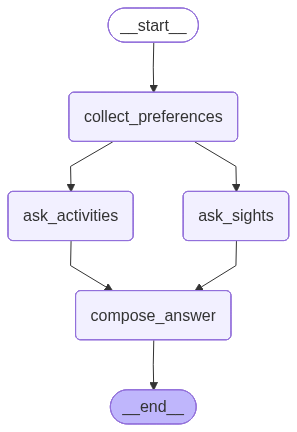

In [59]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [60]:
initial = GState(
    messages = [HumanMessage("I like street food and wine tasting. I will travel to Florence.")],
    city = "",
    interests = [],
    activities = [],
    sights = []
)
config = {"configurable": {"thread_id": "demo-thread-1"}}
final_result1 = app.invoke(initial, config=config)
print(final_result1["messages"][-1].content)

## Running collect_preferences node ##
##############################
city='Florence' interests=['street food', 'wine tasting']
##############################
## Running ask_activities node ##
## Running ask_sights node ##
## Running compose_answer node ##
I like street food and wine tasting. I will travel to Florence.


In [61]:
dump_state(final_result1)

{
  "messages": [
    {
      "type": "human",
      "content": "I like street food and wine tasting. I will travel to Florence."
    }
  ],
  "city": "Florence",
  "interests": [
    "street food",
    "wine tasting"
  ],
  "activities": [
    "Florence is a fantastic destination with a rich culinary scene and vibrant street culture. Here are three activities that combine your love of street food and wine tasting:",
    "1. **Florentine Street Food Tour**: Join a guided street food tour to sample some of Florence's most delicious street foods. You can taste favorites like Lampredotto (a traditional tripe sandwich), schiacciata (a Tuscan flatbread), and various local pastries. Many tours also include stops at local markets, where you can soak in the atmosphere and learn about Tuscan ingredients.",
    "2. **Wine Tasting in Chianti**: Take a day trip to the nearby Chianti region, renowned for its vineyards and stunning landscapes. Book a wine tasting tour that includes visits to local w

In [62]:
final_result2 = app.invoke(
    {"messages": [HumanMessage("Now I'm going to visit Tokyo")]},
    config=config
)
print(final_result2["messages"][-1].content)

## Running collect_preferences node ##
##############################
city='Tokyo' interests=[]
##############################
## Running ask_activities node ##
## Running ask_sights node ##
## Running compose_answer node ##
Now I'm going to visit Tokyo


In [63]:
dump_state(final_result2)

{
  "messages": [
    {
      "type": "human",
      "content": "I like street food and wine tasting. I will travel to Florence."
    },
    {
      "type": "human",
      "content": "Now I'm going to visit Tokyo"
    }
  ],
  "city": "Tokyo",
  "interests": [],
  "activities": [
    "Sure! Here are three activities to enjoy while visiting Tokyo:",
    "1. **Explore Shibuya Crossing and Hachiko Statue**:",
    "   Visit the iconic Shibuya Crossing, famously known as one of the busiest pedestrian intersections in the world. After witnessing the organized chaos of the crossing, take a moment to visit the nearby Hachiko Statue, which pays tribute to the loyal Akita dog who waited for his master every day at Shibuya Station.",
    "2. **Visit Asakusa and Senso-ji Temple**:",
    "   Immerse yourself in traditional Japanese culture by visiting Senso-ji, Tokyo's oldest temple located in Asakusa. Take a stroll down Nakamise Street, where you can find various traditional snacks and souvenirs. 

In [64]:
# After Tokyo query
print("\n" + "="*50)
print("COMPLETE MULTI-CITY TRIP PLAN")
print("="*50)
from IPython.display import Markdown, display
display(Markdown(final_result2["trip_plan"]))


COMPLETE MULTI-CITY TRIP PLAN


Markdown document containing all trip advices# Trip Plan for Florence

## Interesting Places to Visit

Florence is a city rich in history, art, and culture. Here are three of the most interesting places to visit:

1. **Uffizi Gallery (Galleria degli Uffizi)**: One of the most important art museums in the world, the Uffizi Gallery houses an incredible collection of Renaissance art. Visitors can admire masterpieces by artists such as Botticelli, Michelangelo, Leonardo da Vinci, and Raphael. The gallery’s layout encourages a fascinating journey through the evolution of art, making it a must-visit for art lovers.

2. **Florence Cathedral (Duomo di Firenze)**: The iconic Duomo, with its stunning dome designed by Brunelleschi, is a masterpiece of Gothic architecture. Climbing to the top of the dome offers breathtaking views of the city. Inside, the cathedral features beautiful frescoes and intricate details. The adjoining Baptistery and Giotto's Campanile are also worth exploring, as they are significant parts of Florence's architectural heritage.

3. **Ponte Vecchio**: This famous medieval stone bridge is known for its unique shops built along it, primarily jewelers and goldsmiths. The Ponte Vecchio offers picturesque views of the Arno River and is one of the most recognizable landmarks in Florence. A walk across the bridge is a delightful experience, especially at sunset when the city glows in soft hues.

These sites offer a blend of art, history, and stunning architecture that encapsulates the essence of Florence.

## Activities to Experience

Florence is a fantastic destination with a rich culinary scene and vibrant street culture. Here are three activities that combine your love of street food and wine tasting:

1. **Florentine Street Food Tour**: Join a guided street food tour to sample some of Florence's most delicious street foods. You can taste favorites like Lampredotto (a traditional tripe sandwich), schiacciata (a Tuscan flatbread), and various local pastries. Many tours also include stops at local markets, where you can soak in the atmosphere and learn about Tuscan ingredients.

2. **Wine Tasting in Chianti**: Take a day trip to the nearby Chianti region, renowned for its vineyards and stunning landscapes. Book a wine tasting tour that includes visits to local wineries where you can sample Chianti wines alongside some artisanal cheeses and cured meats. This will give you a taste of the region’s rich viticulture and allow you to enjoy the beautiful countryside.

3. **Cooking Class with Wine Pairing**: Participate in a cooking class that focuses on traditional Tuscan dishes paired with local wines. Many classes include a market visit to choose fresh ingredients, followed by hands-on cooking instruction. After preparing the meal, you’ll enjoy a sit-down dinner featuring your dishes, all paired with exquisite local wines.

These activities will give you a great blend of street food experiences and wine tasting that Florence is famous for!

  # Trip Plan to Tokyo

## Interesting Places to Visit
Tokyo is a vibrant city with a blend of tradition and modernity. Here are three interesting places to visit:
1. **Shibuya Crossing**: Often considered the busiest pedestrian crossing in the world, Shibuya Crossing is an iconic symbol of Tokyo's hustle and bustle. Surrounding the crossing are shops, restaurants, and the famous Hachiko statue, which commemorates a loyal dog. Visitors can experience the organized chaos and vibrant atmosphere, especially at night when the neon lights illuminate the area.

2. **Senso-ji Temple**: Located in Asakusa, Senso-ji is Tokyo's oldest temple, dating back to the 7th century. The approach to the temple, called Nakamise Street, is lined with traditional shops selling snacks and souvenirs. The temple itself is a beautiful example of traditional Japanese architecture and offers a serene contrast to the surrounding urban landscape. It's an excellent spot to experience Japanese culture and spirituality.

3. **Akihabara**: Known as the center of otaku culture, Akihabara is a haven for anime, manga, and electronics enthusiasts. The district is filled with themed cafes, anime shops, and electronic stores. Visitors can explore various specialty shops, participate in cosplay experiences, and discover the vibrant subculture that defines this unique area of Tokyo.

Each of these locations offers a different perspective on Tokyo, showcasing its rich history, cultural diversity, and modern innovations.

## Suggested Activities
Here are three activities to enjoy while visiting Tokyo:
1. **Explore Shibuya Crossing and Hachiko Statue**:  
   Visit the iconic Shibuya Crossing, famously known as one of the busiest pedestrian intersections in the world. After witnessing the organized chaos of the crossing, take a moment to visit the nearby Hachiko Statue, which pays tribute to the loyal Akita dog who waited for his master every day at Shibuya Station.

2. **Visit Asakusa and Senso-ji Temple**:  
   Immerse yourself in traditional Japanese culture by visiting Senso-ji, Tokyo's oldest temple located in Asakusa. Take a stroll down Nakamise Street, where you can find various traditional snacks and souvenirs. Don't forget to try some freshly made melon bread or ningyo-yaki (sweet cakes filled with red bean paste).

3. **Experience Akihabara's Otaku Culture**:  
   Delve into the world of Japanese pop culture in Akihabara, known as the hub for anime, manga, and video games. Explore the numerous shops filled with collectibles and merchandise. If interested, you can also visit a themed café, such as a maid café or an anime-themed café, for a unique dining experience.

Enjoy your trip to Tokyo!

  

  